**Citi Bike Trip Duration Project**

*In this notebook, we explore Citi Bike trips from May 2025 and train a few regression models to predict trip duration in minutes.*


# Project Overview

The goal is to predict `trip_duration_minutes` using information that is available when the ride starts.

This is a good regression problem for this dataset because the target is clear, easy to interpret, and connected to real usage patterns in the Citi Bike system.


# The Dataset

We use the official Citi Bike trip history data for May 2025.

The five monthly files were combined into one CSV:

- `202505-citibike-tripdata.csv`
- about 805 MB
- 4,325,553 trip rows

The main variables are timestamps, station names and IDs, coordinates, bike type, and rider type.


In [1]:
# Python ≥3.8 is required
import sys
assert sys.version_info >= (3, 8)

# Scikit-Learn ≥1.3 is required
import sklearn
assert sklearn.__version__ >= "1.3"

# Common imports
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeRegressor

np.random.seed(67)

pd.set_option("display.max_columns", 50)
mpl.rc("axes", labelsize=14)
mpl.rc("xtick", labelsize=12)
mpl.rc("ytick", labelsize=12)
plt.rcParams["figure.figsize"] = (9, 5)

PROJECT_ROOT_DIR = "."
CHAPTER_ID = "citi_bike_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)


def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)


CSV_PATH = Path("202505-citibike-tripdata.csv")

CSV_PATH

PosixPath('202505-citibike-tripdata.csv')

In [2]:
file_size_mb = CSV_PATH.stat().st_size / (1024 ** 2)
print(f'CSV path: {CSV_PATH}')
print(f'File size: {file_size_mb:,.1f} MB')

CSV path: 202505-citibike-tripdata.csv
File size: 805.3 MB


# Load the Data


In [3]:
DATE_COLUMNS = ['started_at', 'ended_at']
RANDOM_STATE = 42

df_full = pd.read_csv(CSV_PATH, parse_dates=DATE_COLUMNS, low_memory=False)
df_clean = df_full.dropna().copy()

print(f'Full dataset shape: {df_full.shape}')
print(f'Clean dataset shape after dropna(): {df_clean.shape}')
print(f'Rows dropped because of missing values: {len(df_full) - len(df_clean):,}')
display(df_clean)

Full dataset shape: (4325553, 13)
Clean dataset shape after dropna(): (4311373, 13)
Rows dropped because of missing values: 14,180


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,9DD48ABED65F7015,classic_bike,2025-05-04 14:19:21.329,2025-05-04 14:24:15.721,W Broadway & Spring St,5569.06,Lafayette St & Grand St,5422.09,40.724947,-74.001659,40.720280,-73.998790,member
1,FF82206785FF6C44,classic_bike,2025-05-07 17:41:53.824,2025-05-07 17:50:02.742,W Broadway & Spring St,5569.06,Lafayette St & Grand St,5422.09,40.724947,-74.001659,40.720280,-73.998790,member
2,5AEFCBE946C15D90,electric_bike,2025-05-11 20:21:07.908,2025-05-11 20:33:39.623,Coffey St & Ferris St,4137.14,3 St & 7 Ave,3905.15,40.678184,-74.017017,40.670384,-73.978397,member
3,6263552B7DC7E709,electric_bike,2025-05-08 14:06:13.781,2025-05-08 14:15:52.413,Coffey St & Ferris St,4137.14,Fulton St & Adams St,4637.06,40.678184,-74.017017,40.692418,-73.989495,member
4,D421E8FF99ED9C1B,electric_bike,2025-05-02 16:32:21.540,2025-05-02 16:39:50.612,North Moore St & Greenwich St,5470.12,Lafayette St & Grand St,5422.09,40.720195,-74.010301,40.720280,-73.998790,member
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4325548,C73981593AE04116,classic_bike,2025-05-31 17:42:13.433,2025-05-31 17:56:27.359,W 26 St & 10 Ave,6382.05,E 20 St & FDR Dr,5886.13,40.749718,-74.002950,40.733209,-73.975681,casual
4325549,01418563828B2B47,electric_bike,2025-05-31 18:56:38.228,2025-05-31 19:08:24.745,Carroll St & Washington Ave,3887.03,West Drive & Prospect Park West,3651.04,40.668674,-73.961815,40.661063,-73.979453,casual
4325550,62BF0E22262F3243,electric_bike,2025-05-24 20:57:51.835,2025-05-24 21:05:39.601,Turner Pl & Coney Island Ave,3157.08,West Drive & Prospect Park West,3651.04,40.645210,-73.970730,40.661063,-73.979453,casual
4325551,C0697C866DE507E3,electric_bike,2025-05-19 20:26:19.231,2025-05-19 20:29:29.794,51 St & Queens Blvd,6167.03,61 St & Woodside Ave,6191.06,40.742900,-73.913950,40.745010,-73.903600,casual


In [4]:
display(df_clean.head())
display(df_clean.dtypes)
display(df_clean.isna().sum().sort_values(ascending=False))

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,9DD48ABED65F7015,classic_bike,2025-05-04 14:19:21.329,2025-05-04 14:24:15.721,W Broadway & Spring St,5569.06,Lafayette St & Grand St,5422.09,40.724947,-74.001659,40.720280,-73.998790,member
1,FF82206785FF6C44,classic_bike,2025-05-07 17:41:53.824,2025-05-07 17:50:02.742,W Broadway & Spring St,5569.06,Lafayette St & Grand St,5422.09,40.724947,-74.001659,40.720280,-73.998790,member
2,5AEFCBE946C15D90,electric_bike,2025-05-11 20:21:07.908,2025-05-11 20:33:39.623,Coffey St & Ferris St,4137.14,3 St & 7 Ave,3905.15,40.678184,-74.017017,40.670384,-73.978397,member
3,6263552B7DC7E709,electric_bike,2025-05-08 14:06:13.781,2025-05-08 14:15:52.413,Coffey St & Ferris St,4137.14,Fulton St & Adams St,4637.06,40.678184,-74.017017,40.692418,-73.989495,member
4,D421E8FF99ED9C1B,electric_bike,2025-05-02 16:32:21.540,2025-05-02 16:39:50.612,North Moore St & Greenwich St,5470.12,Lafayette St & Grand St,5422.09,40.720195,-74.010301,40.720280,-73.998790,member


ride_id                          str
rideable_type                    str
started_at            datetime64[us]
ended_at              datetime64[us]
start_station_name               str
start_station_id                 str
end_station_name                 str
end_station_id                   str
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                    str
dtype: object

ride_id               0
rideable_type         0
started_at            0
ended_at              0
start_station_name    0
start_station_id      0
end_station_name      0
end_station_id        0
start_lat             0
start_lng             0
end_lat               0
end_lng               0
member_casual         0
dtype: int64

# Take a Quick Look at the Data


In [5]:
df_clean['trip_duration_seconds'] = (df_clean['ended_at'] - df_clean['started_at']).dt.total_seconds()
df_clean['trip_duration_minutes'] = df_clean['trip_duration_seconds'] / 60

duration_checks = {
    'clean_rows': len(df_clean),
    'missing_duration': int(df_clean['trip_duration_minutes'].isna().sum()),
    'non_positive_duration': int((df_clean['trip_duration_minutes'] <= 0).sum()),
    'duration_min_minutes': df_clean['trip_duration_minutes'].min(),
    'duration_median_minutes': df_clean['trip_duration_minutes'].median(),
    'duration_mean_minutes': df_clean['trip_duration_minutes'].mean(),
    'duration_max_minutes': df_clean['trip_duration_minutes'].max(),
}
duration_checks

{'clean_rows': 4311373,
 'missing_duration': 0,
 'non_positive_duration': 0,
 'duration_min_minutes': np.float64(1.00055),
 'duration_median_minutes': np.float64(9.135633333333335),
 'duration_mean_minutes': np.float64(12.89164123111516),
 'duration_max_minutes': np.float64(1498.8088)}

In [6]:
duplicate_ride_ids = df_clean['ride_id'].duplicated().sum()

# Roughly NYC-area 
coord_mask = (
    df_clean['start_lat'].between(40.3, 41.1) &
    df_clean['end_lat'].between(40.3, 41.1) &
    df_clean['start_lng'].between(-74.5, -73.4) &
    df_clean['end_lng'].between(-74.5, -73.4)
)

quality_checks = pd.Series({
    'duplicate_ride_ids_in_clean_data': int(duplicate_ride_ids),
    'rows_with_missing_start_station_id': int(df_clean['start_station_id'].isna().sum()),
    'rows_with_missing_end_station_id': int(df_clean['end_station_id'].isna().sum()),
    'rows_with_missing_coordinates': int(df_clean[['start_lat', 'start_lng', 'end_lat', 'end_lng']].isna().any(axis=1).sum()),
    'rows_outside_broad_nyc_coordinate_check': int((~coord_mask).sum()),
})

display(quality_checks)

duplicate_ride_ids_in_clean_data           0
rows_with_missing_start_station_id         0
rows_with_missing_end_station_id           0
rows_with_missing_coordinates              0
rows_outside_broad_nyc_coordinate_check    0
dtype: int64

In [7]:
full_missing = df_full.isna().sum().rename('missing_count').reset_index().rename(columns={'index': 'column'})
full_missing['missing_percent'] = full_missing['missing_count'] / len(df_full) * 100

full_summary = {
    'full_rows_before_dropna': len(df_full),
    'clean_rows_after_dropna': len(df_clean),
    'rows_removed_by_dropna': len(df_full) - len(df_clean),
    'duplicate_ride_ids_in_full_data': int(df_full['ride_id'].duplicated().sum()),
    'duplicate_ride_ids_in_clean_data': int(df_clean['ride_id'].duplicated().sum()),
    'rider_type_counts_clean_data': df_clean['member_casual'].value_counts(dropna=False).to_dict(),
    'bike_counts_clean_data': df_clean['rideable_type'].value_counts(dropna=False).to_dict(),
    'non_positive_duration_clean_data': int((df_clean['trip_duration_minutes'] <= 0).sum()),
}

display(full_summary)
display(full_missing.sort_values('missing_percent', ascending=False))

{'full_rows_before_dropna': 4325553,
 'clean_rows_after_dropna': 4311373,
 'rows_removed_by_dropna': 14180,
 'duplicate_ride_ids_in_full_data': 0,
 'duplicate_ride_ids_in_clean_data': 0,
 'rider_type_counts_clean_data': {'member': 3475064, 'casual': 836309},
 'bike_counts_clean_data': {'electric_bike': 2995108, 'classic_bike': 1316265},
 'non_positive_duration_clean_data': 0}

,column,missing_count,missing_percent
7,end_station_id,12726,0.294205
10,end_lat,12706,0.293743
11,end_lng,12706,0.293743
6,end_station_name,12343,0.285351
4,start_station_name,1691,0.039093
5,start_station_id,1691,0.039093
8,start_lat,1691,0.039093
9,start_lng,1691,0.039093
0,ride_id,0,0.000000
1,rideable_type,0,0.000000


# Preparing the Data 

- drop incomplete rows
- compute the target from the timestamps
- create time features
- compute straight-line distance
- one-hot encode bike type and rider type
- scale numeric features for linear regression
- cap the top 1% longest rides for the first model


We leave station names and station IDs out of the models, and we only keep features that would be known when the ride starts.


In [8]:
def add_model_features(df):
    out = df.copy()
    out['trip_duration_minutes'] = (out['ended_at'] - out['started_at']).dt.total_seconds() / 60
    out['start_hour'] = out['started_at'].dt.hour
    out['start_dayofweek'] = out['started_at'].dt.dayofweek
    out['is_weekend'] = out['start_dayofweek'].isin([5, 6]).astype(int)
    out['start_month'] = out['started_at'].dt.month
    out['hour_sin'] = np.sin(2 * np.pi * out['start_hour'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['start_hour'] / 24)
    out['dow_sin'] = np.sin(2 * np.pi * out['start_dayofweek'] / 7)
    out['dow_cos'] = np.cos(2 * np.pi * out['start_dayofweek'] / 7)

    lat1 = np.radians(out['start_lat'])
    lon1 = np.radians(out['start_lng'])
    lat2 = np.radians(out['end_lat'])
    lon2 = np.radians(out['end_lng'])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    out['trip_distance_miles'] = 3958.756 * c

    return out

df_features = add_model_features(df_clean)
display(df_features[['trip_duration_minutes', 'trip_distance_miles', 'start_hour', 'start_dayofweek', 'is_weekend']].describe())

,trip_duration_minutes,trip_distance_miles,start_hour,start_dayofweek,is_weekend
count,4.311373e+06,4.311373e+06,4.311373e+06,4.311373e+06,4.311373e+06
mean,1.289164e+01,1.281091e+00,1.411752e+01,3.160376e+00,3.077289e-01
std,1.859840e+01,1.092726e+00,5.084945e+00,1.927434e+00,4.615538e-01
min,1.000550e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.284950e+00,5.441454e-01,1.000000e+01,1.000000e+00,0.000000e+00
50%,9.135633e+00,9.599184e-01,1.500000e+01,3.000000e+00,0.000000e+00
75%,1.586418e+01,1.678530e+00,1.800000e+01,5.000000e+00,1.000000e+00
max,1.498809e+03,1.759820e+01,2.300000e+01,6.000000e+00,1.000000e+00


# Explore the Data




,trip_duration_minutes
count,4311373.00
mean,12.89
std,18.60
min,1.00
25%,5.28
50%,9.14
75%,15.86
90%,25.68
95%,33.79
99%,59.15


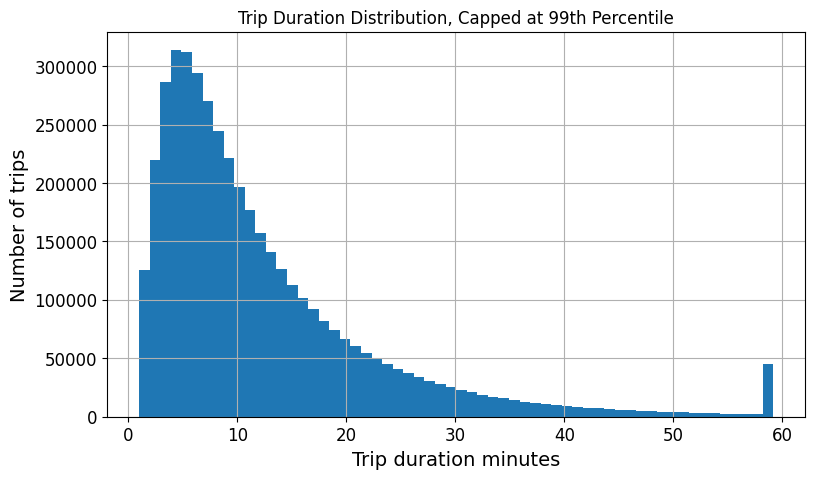

In [9]:
plot_df = df_features.dropna(subset=['trip_duration_minutes']).copy()

duration_summary = (
    plot_df['trip_duration_minutes']
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .rename('trip_duration_minutes')
    .to_frame()
)
display(duration_summary.round(2))

duration_cap = plot_df['trip_duration_minutes'].quantile(0.99)
plot_df['duration_minutes_capped_99'] = plot_df['trip_duration_minutes'].clip(upper=duration_cap)

ax = plot_df['duration_minutes_capped_99'].hist(bins=60)
ax.set_title('Trip Duration Distribution, Capped at 99th Percentile')
ax.set_xlabel('Trip duration minutes')
ax.set_ylabel('Number of trips')
plt.show()


,trip_count,median_duration,mean_duration
start_hour,,,
0,61897,9.03,12.76
1,36211,8.85,12.71
2,22902,8.76,12.66
3,15208,8.40,12.63
4,14060,7.63,11.69
5,29852,6.38,9.27
6,83603,6.81,9.47
7,174480,7.54,10.23
8,257469,8.13,10.87


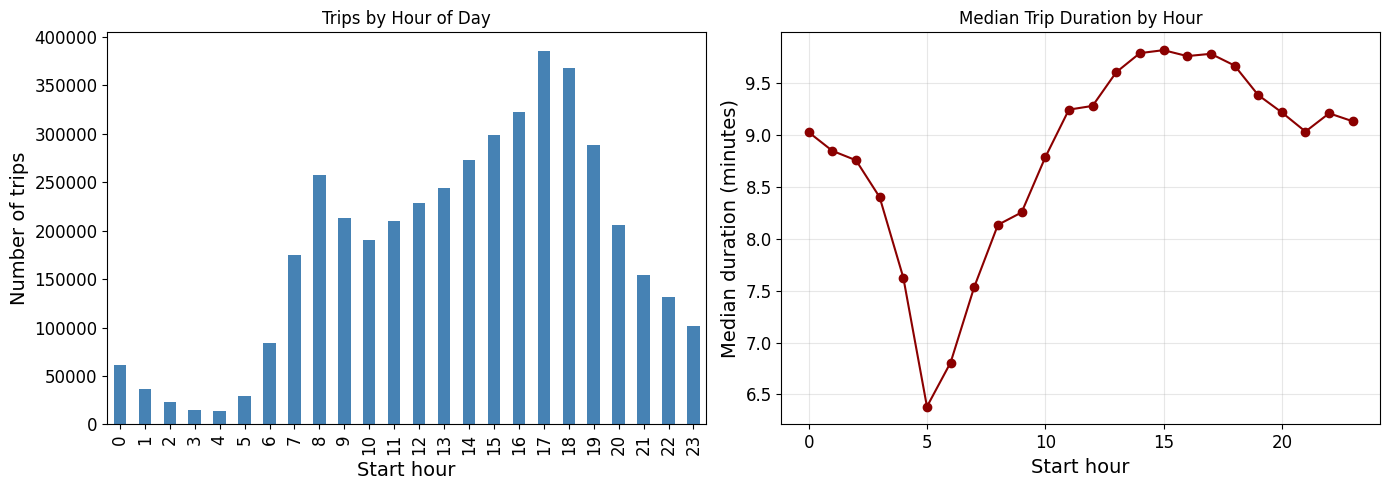

In [10]:
hour_summary = (
    df_features.groupby('start_hour')['trip_duration_minutes']
    .agg(trip_count='size', median_duration='median', mean_duration='mean')
)
display(hour_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hour_summary['trip_count'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Trips by Hour of Day')
axes[0].set_xlabel('Start hour')
axes[0].set_ylabel('Number of trips')

hour_summary['median_duration'].plot(ax=axes[1], marker='o', color='darkred')
axes[1].set_title('Median Trip Duration by Hour')
axes[1].set_xlabel('Start hour')
axes[1].set_ylabel('Median duration (minutes)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Trip volume peaks in the late afternoon, especially around 5 to 6 pm, which looks like a strong commute pattern. But the busiest hours are not the longest trips: median duration is shortest in the early morning commute window and rises toward late morning and afternoon. That tells us start time matters, but not only because it changes traffic volume.


,trip_count,median_duration,mean_duration
Mon,527988,8.99,12.96
Tue,577739,8.53,11.73
Wed,451695,8.09,11.15
Thu,717373,8.71,11.94
Fri,709844,8.81,12.22
Sat,807469,10.59,14.88
Sun,519265,10.19,14.77


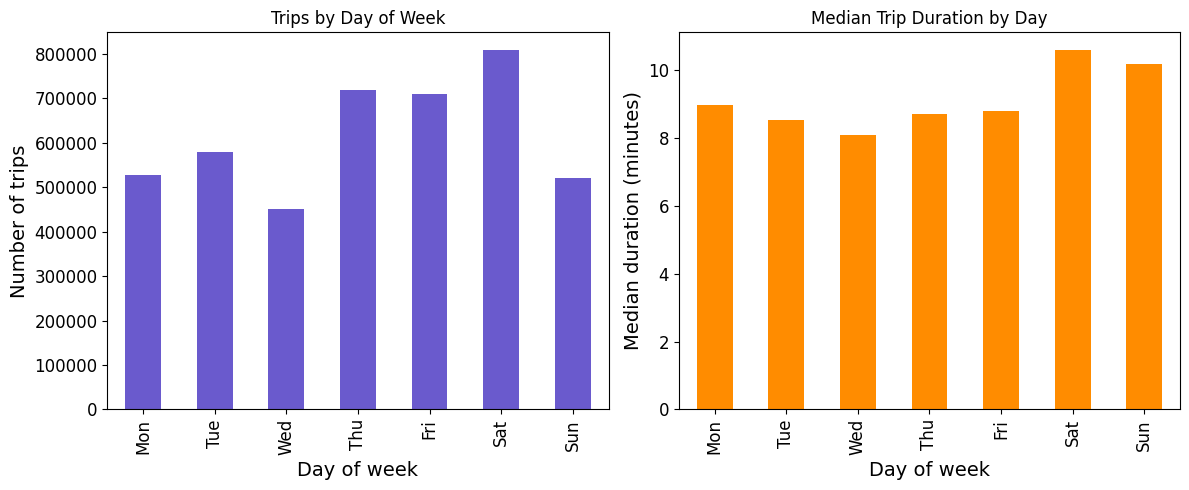

In [11]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

day_summary = (
    df_features.groupby('start_dayofweek')['trip_duration_minutes']
    .agg(trip_count='size', median_duration='median', mean_duration='mean')
)
day_summary.index = [day_names[i] for i in day_summary.index]
display(day_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

day_summary['trip_count'].plot(kind='bar', ax=axes[0], color='slateblue')
axes[0].set_title('Trips by Day of Week')
axes[0].set_xlabel('Day of week')
axes[0].set_ylabel('Number of trips')

day_summary['median_duration'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Median Trip Duration by Day')
axes[1].set_xlabel('Day of week')
axes[1].set_ylabel('Median duration (minutes)')

plt.tight_layout()
plt.show()


Saturday is the busiest day in the cleaned data, and weekend rides are also longer. The median trip is about 10.59 minutes on Saturday and 10.19 on Sunday, compared with roughly 8 to 9 minutes on weekdays. That suggests the system is capturing both commuting and more leisure-style riding, so weekend indicators should help the model.


,trip_count,median_duration,mean_duration
member_casual,,,
casual,836309,13.43,19.48
member,3475064,8.35,11.31


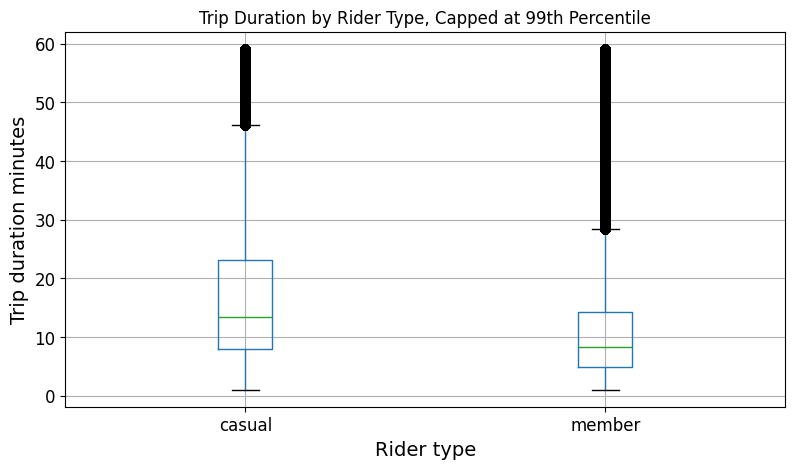

In [12]:
member_duration_summary = (
    plot_df.groupby('member_casual')['trip_duration_minutes']
    .agg(trip_count='size', median_duration='median', mean_duration='mean')
)
display(member_duration_summary.round(2))

ax = plot_df.boxplot(column='duration_minutes_capped_99', by='member_casual')
ax.set_title('Trip Duration by Rider Type, Capped at 99th Percentile')
ax.set_xlabel('Rider type')
ax.set_ylabel('Trip duration minutes')
plt.suptitle('')
plt.show()


Rider type matters a lot. Casual riders have a median trip duration of about 13.43 minutes, while members are closer to 8.35 minutes. 

,trip_count,median_duration,mean_duration
rideable_type,,,
classic_bike,1316265,8.65,13.27
electric_bike,2995108,9.33,12.72


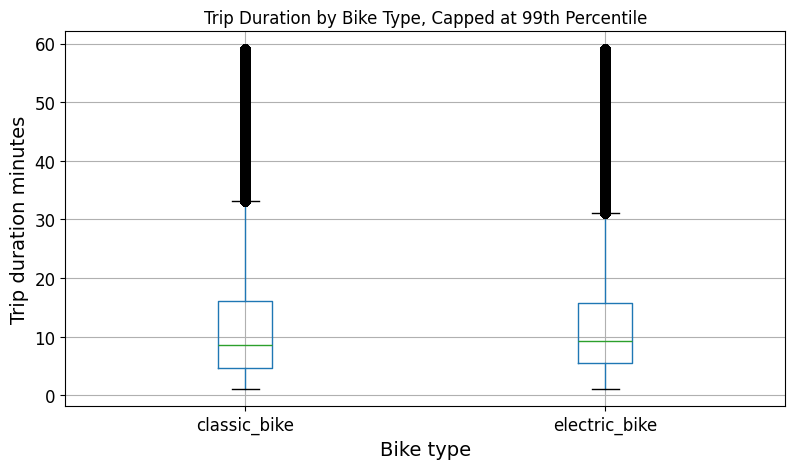

In [13]:
bike_duration_summary = (
    plot_df.groupby('rideable_type')['trip_duration_minutes']
    .agg(trip_count='size', median_duration='median', mean_duration='mean')
)
display(bike_duration_summary.round(2))

ax = plot_df.boxplot(column='duration_minutes_capped_99', by='rideable_type')
ax.set_title('Trip Duration by Bike Type, Capped at 99th Percentile')
ax.set_xlabel('Bike type')
ax.set_ylabel('Trip duration minutes')
plt.suptitle('')
plt.show()


 Electric bikes have a slightly higher median duration than classic bikes, while classic bikes have a slightly higher mean because of a longer tail of very long rides.

,trip_count,median_distance_miles,mean_distance_miles
rideable_type,,,
classic_bike,1316265,0.72,0.99
electric_bike,2995108,1.08,1.41


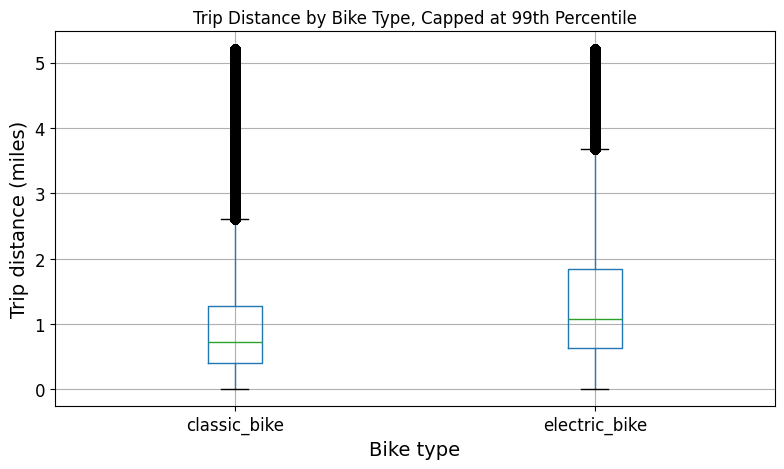

In [14]:
distance_plot_df = df_features.dropna(subset=['trip_distance_miles', 'rideable_type']).copy()

distance_summary = (
    distance_plot_df.groupby('rideable_type')['trip_distance_miles']
    .agg(trip_count='size', median_distance_miles='median', mean_distance_miles='mean')
)
display(distance_summary.round(2))

distance_cap = distance_plot_df['trip_distance_miles'].quantile(0.99)
distance_plot_df['trip_distance_miles_capped_99'] = distance_plot_df['trip_distance_miles'].clip(upper=distance_cap)

ax = distance_plot_df.boxplot(column='trip_distance_miles_capped_99', by='rideable_type')
ax.set_title('Trip Distance by Bike Type, Capped at 99th Percentile')
ax.set_xlabel('Bike type')
ax.set_ylabel('Trip distance (miles)')
plt.suptitle('')
plt.show()

Straight-line trip distance gives us another useful analysis variable. Electric bikes tend to cover slightly longer distances, but we do not include this variable in the prediction model because the end coordinates are not known when the ride starts.

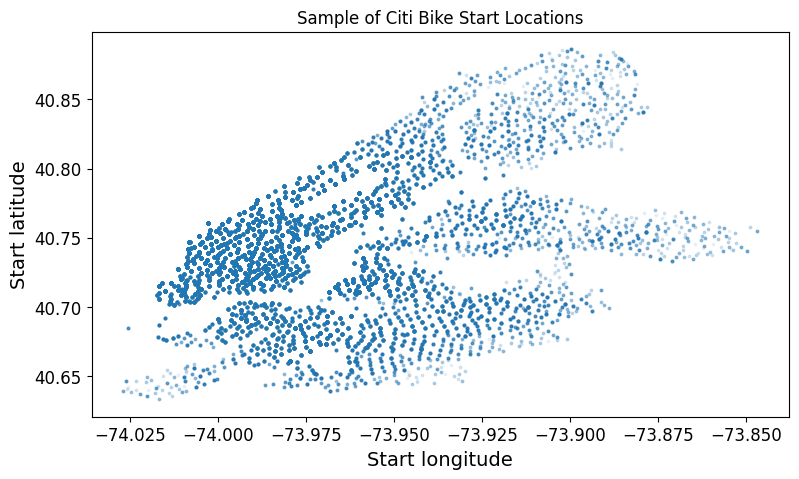

In [15]:
location_df = df_features.dropna(subset=['start_lat', 'start_lng'])
location_plot_df = location_df.sample(n=min(100_000, len(location_df)), random_state=RANDOM_STATE)

ax = location_plot_df.plot(
    kind='scatter',
    x='start_lng',
    y='start_lat',
    alpha=0.08,
    s=3,
)
ax.set_title('Sample of Citi Bike Start Locations')
ax.set_xlabel('Start longitude')
ax.set_ylabel('Start latitude')
plt.show()


# Traffic Hotspots and Bike Type Mix

Now let's look at where trips are concentrated and how electric-bike usage changes across busy areas.


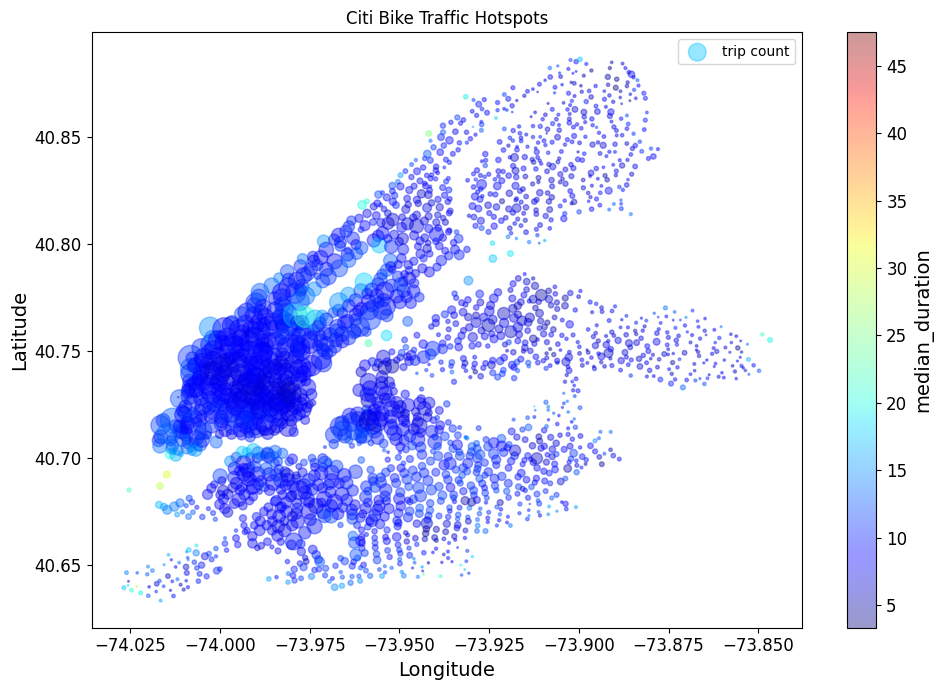

In [16]:
traffic_df = df_features.dropna(subset=['start_lat', 'start_lng', 'trip_duration_minutes']).copy()

station_traffic = (
    traffic_df.groupby(['start_lng', 'start_lat'])
    .agg(
        trip_count=('ride_id', 'size'),
        median_duration=('trip_duration_minutes', 'median'),
    )
    .reset_index()
)

station_traffic.plot(
    kind='scatter',
    x='start_lng',
    y='start_lat',
    alpha=0.4,
    s=station_traffic['trip_count'] / 45,
    label='trip count',
    figsize=(10, 7),
    c='median_duration',
    cmap=plt.get_cmap('jet'),
    colorbar=True,
    sharex=False,
)
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Citi Bike Traffic Hotspots')
save_fig('citi_bike_hotspot_map')
plt.show()


,share_percent
rideable_type,
electric_bike,69.47
classic_bike,30.53


rideable_type,classic_bike,electric_bike
member_casual,,
casual,27.05,72.95
member,31.37,68.63


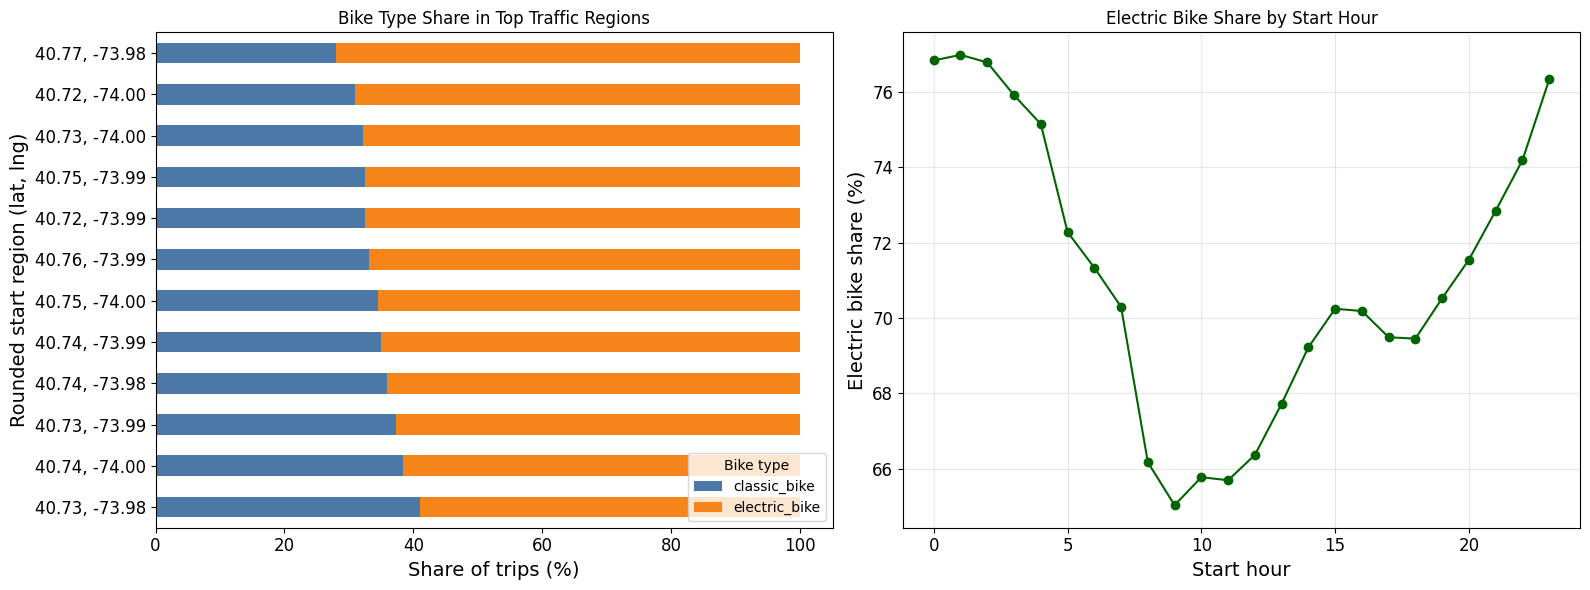

In [17]:
traffic_df = traffic_df.copy()
traffic_df['region_lat'] = traffic_df['start_lat'].round(2)
traffic_df['region_lng'] = traffic_df['start_lng'].round(2)
traffic_df['start_region'] = (
    traffic_df['region_lat'].map(lambda x: f'{x:.2f}') + ', ' +
    traffic_df['region_lng'].map(lambda x: f'{x:.2f}')
)

region_summary = (
    traffic_df.groupby('start_region')
    .agg(trip_count=('ride_id', 'size'))
    .sort_values('trip_count', ascending=False)
    .head(12)
)
top_region_labels = region_summary.index.tolist()

overall_bike_share = (
    traffic_df['rideable_type']
    .value_counts(normalize=True)
    .mul(100)
    .rename('share_percent')
    .to_frame()
)
display(overall_bike_share.round(2))

bike_by_rider = pd.crosstab(
    traffic_df['member_casual'],
    traffic_df['rideable_type'],
    normalize='index',
).mul(100)
display(bike_by_rider.round(2))

region_bike_share = (
    traffic_df[traffic_df['start_region'].isin(top_region_labels)]
    .groupby(['start_region', 'rideable_type'])
    .size()
    .unstack(fill_value=0)
    .reindex(top_region_labels)
    .reindex(columns=['classic_bike', 'electric_bike'], fill_value=0)
)
region_bike_share = region_bike_share.div(region_bike_share.sum(axis=1), axis=0).mul(100)

hour_bike_share = (
    traffic_df.groupby('start_hour')
    .agg(electric_share=('rideable_type', lambda s: s.eq('electric_bike').mean() * 100))
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_bike_share.sort_values('electric_bike').plot(
    kind='barh',
    stacked=True,
    ax=axes[0],
    color=['#4c78a8', '#f58518'],
)
axes[0].set_title('Bike Type Share in Top Traffic Regions')
axes[0].set_xlabel('Share of trips (%)')
axes[0].set_ylabel('Rounded start region (lat, lng)')
axes[0].legend(title='Bike type', loc='lower right')

hour_bike_share['electric_share'].plot(ax=axes[1], marker='o', color='darkgreen')
axes[1].set_title('Electric Bike Share by Start Hour')
axes[1].set_xlabel('Start hour')
axes[1].set_ylabel('Electric bike share (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Training Models

From this point on, the models only use information that would be available when the ride starts.


In [18]:
# keep only features that are known when the ride starts
model_attribs = [
    'rideable_type',
    'member_casual',
    'start_hour',
    'start_dayofweek',
    'is_weekend',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'start_lat',
    'start_lng',
]

trip_data = df_features[model_attribs + ['started_at', 'trip_duration_minutes']].dropna().copy()
trip_data = trip_data[trip_data['trip_duration_minutes'] > 0].copy()
trip_duration_cap = trip_data['trip_duration_minutes'].quantile(0.99)
trip_data = trip_data[trip_data['trip_duration_minutes'] <= trip_duration_cap].copy()
trip_data = trip_data.sort_values('started_at').reset_index(drop=True)

# keep the split chronological by disabling shuffling
trip_train_valid_set, trip_test_set = train_test_split(
    trip_data,
    test_size=0.15,
    shuffle=False,
)
trip_train_set, trip_valid_set = train_test_split(
    trip_train_valid_set,
    test_size=0.15 / 0.85,
    shuffle=False,
)

trip_train = trip_train_set.drop(['started_at', 'trip_duration_minutes'], axis=1)
trip_valid = trip_valid_set.drop(['started_at', 'trip_duration_minutes'], axis=1)
trip_test = trip_test_set.drop(['started_at', 'trip_duration_minutes'], axis=1)

trip_train_labels = trip_train_set['trip_duration_minutes'].copy()
trip_valid_labels = trip_valid_set['trip_duration_minutes'].copy()
trip_test_labels = trip_test_set['trip_duration_minutes'].copy()

model_summary = pd.DataFrame({
    'rows': [len(trip_train_set), len(trip_valid_set), len(trip_test_set)],
    'start_date': [
        trip_train_set['started_at'].min(),
        trip_valid_set['started_at'].min(),
        trip_test_set['started_at'].min(),
    ],
    'end_date': [
        trip_train_set['started_at'].max(),
        trip_valid_set['started_at'].max(),
        trip_test_set['started_at'].max(),
    ],
}, index=['train', 'validation', 'test'])
model_summary.loc['duration_cap_minutes', 'rows'] = round(trip_duration_cap, 2)
display(model_summary)


,rows,start_date,end_date
train,2987781.00,2025-04-30 23:07:09.714,2025-05-21 23:34:42.958
validation,640239.00,2025-05-21 23:34:43.008,2025-05-27 16:04:48.979
test,640239.00,2025-05-27 16:04:49.458,2025-05-31 23:58:06.793
duration_cap_minutes,59.15,NaT,NaT


In [19]:
# these are all available at the moment the ride begins
num_attribs = [
    'start_hour',
    'start_dayofweek',
    'is_weekend',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'start_lat',
    'start_lng',
]
cat_attribs = ['rideable_type', 'member_casual']


def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('std_scaler', StandardScaler()),
])

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_attribs),
])

trip_train_prepared = full_pipeline.fit_transform(trip_train)
trip_valid_prepared = full_pipeline.transform(trip_valid)
trip_test_prepared = full_pipeline.transform(trip_test)

lin_reg = LinearRegression()
lin_reg.fit(trip_train_prepared, trip_train_labels)

lin_valid_pred = lin_reg.predict(trip_valid_prepared)
lin_test_pred = lin_reg.predict(trip_test_prepared)

lin_valid_mae, lin_valid_rmse, lin_valid_r2 = evaluate_regression(trip_valid_labels, lin_valid_pred)
lin_test_mae, lin_test_rmse, lin_test_r2 = evaluate_regression(trip_test_labels, lin_test_pred)

lin_scores = pd.DataFrame([
    {
        'model': 'linear_regression',
        'valid_mae': lin_valid_mae,
        'valid_rmse': lin_valid_rmse,
        'valid_r2': lin_valid_r2,
        'test_mae': lin_test_mae,
        'test_rmse': lin_test_rmse,
        'test_r2': lin_test_r2,
    }
])

ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(trip_train_prepared, trip_train_labels)

ridge_valid_pred = ridge_reg.predict(trip_valid_prepared)
ridge_test_pred = ridge_reg.predict(trip_test_prepared)

ridge_valid_mae, ridge_valid_rmse, ridge_valid_r2 = evaluate_regression(trip_valid_labels, ridge_valid_pred)
ridge_test_mae, ridge_test_rmse, ridge_test_r2 = evaluate_regression(trip_test_labels, ridge_test_pred)

ridge_scores = pd.DataFrame([
    {
        'model': 'ridge',
        'valid_mae': ridge_valid_mae,
        'valid_rmse': ridge_valid_rmse,
        'valid_r2': ridge_valid_r2,
        'test_mae': ridge_test_mae,
        'test_rmse': ridge_test_rmse,
        'test_r2': ridge_test_r2,
    }
])

# use a sample for the support vector regressor so the notebook runs faster
svm_train = trip_train.sample(n=min(80_000, len(trip_train)), random_state=42)
svm_train_labels = trip_train_labels.loc[svm_train.index]
svm_train_prepared = full_pipeline.transform(svm_train)

print('Support vector regressor training sample size:', len(svm_train))

svm_reg = LinearSVR(
    C=1.0,
    epsilon=0.5,
    dual='auto',
    max_iter=10_000,
    random_state=42,
)
svm_reg.fit(svm_train_prepared, svm_train_labels)

svm_valid_pred = svm_reg.predict(trip_valid_prepared)
svm_test_pred = svm_reg.predict(trip_test_prepared)

svm_valid_mae, svm_valid_rmse, svm_valid_r2 = evaluate_regression(trip_valid_labels, svm_valid_pred)
svm_test_mae, svm_test_rmse, svm_test_r2 = evaluate_regression(trip_test_labels, svm_test_pred)

svm_scores = pd.DataFrame([
    {
        'model': 'linear_svr',
        'valid_mae': svm_valid_mae,
        'valid_rmse': svm_valid_rmse,
        'valid_r2': svm_valid_r2,
        'test_mae': svm_test_mae,
        'test_rmse': svm_test_rmse,
        'test_r2': svm_test_r2,
    }
])

linear_model_scores = pd.concat([lin_scores, ridge_scores, svm_scores], ignore_index=True).sort_values('valid_mae')
display(linear_model_scores.round(3))

Support vector regressor training sample size: 80000


,model,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
2,linear_svr,6.769,10.079,-0.018,6.21,9.172,-0.027
0,linear_regression,7.161,9.643,0.068,6.65,8.880,0.037
1,ridge,7.161,9.643,0.068,6.65,8.880,0.037


In [ ]:
# use a sample for the tree-based models so the notebook runs faster
sample_train = trip_train.sample(n=min(120_000, len(trip_train)), random_state=42)
sample_train_labels = trip_train_labels.loc[sample_train.index]
sample_valid = trip_valid.sample(n=min(40_000, len(trip_valid)), random_state=42)
sample_valid_labels = trip_valid_labels.loc[sample_valid.index]

forest_pipeline = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_attribs),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_attribs),
], sparse_threshold=0)

sample_train_prepared = forest_pipeline.fit_transform(sample_train)
sample_valid_prepared = forest_pipeline.transform(sample_valid)
trip_valid_prepared_for_forest = forest_pipeline.transform(trip_valid)

print('Tree-based model training sample size:', len(sample_train))
print('Tree-based model validation sample size:', len(sample_valid))


param_grid = [
    {'n_estimators': 120, 'max_depth': 12, 'min_samples_leaf': 5},
    {'n_estimators': 160, 'max_depth': 16, 'min_samples_leaf': 5},
    {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 3},
]

forest_tuning_scores = []
best_forest_params = None
best_forest_mae = float('inf')

for params in param_grid:
    forest_reg = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
    forest_reg.fit(sample_train_prepared, sample_train_labels)
    sample_valid_pred = forest_reg.predict(sample_valid_prepared)
    valid_mae, valid_rmse, valid_r2 = evaluate_regression(sample_valid_labels, sample_valid_pred)

    forest_tuning_scores.append({
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'],
        'min_samples_leaf': params['min_samples_leaf'],
        'valid_mae': valid_mae,
        'valid_rmse': valid_rmse,
        'valid_r2': valid_r2,
    })

    if valid_mae < best_forest_mae:
        best_forest_mae = valid_mae
        best_forest_params = params

forest_tuning_scores = pd.DataFrame(forest_tuning_scores).sort_values('valid_mae').reset_index(drop=True)
display(forest_tuning_scores.round(3))
print('Best random forest parameters:', best_forest_params)


tree_model_specs = [
    {
        'model': 'decision_tree',
        'regressor': DecisionTreeRegressor,
        'params': {
            'random_state': 42,
            'max_depth': 12,
            'min_samples_leaf': 20,
        },
    },
    {
        'model': 'extra_trees',
        'regressor': ExtraTreesRegressor,
        'params': {
            'random_state': 42,
            'n_estimators': 200,
            'max_depth': 18,
            'min_samples_leaf': 3,
            'n_jobs': -1,
        },
    },
    {
        'model': 'hist_gradient_boosting',
        'regressor': HistGradientBoostingRegressor,
        'params': {
            'random_state': 42,
            'learning_rate': 0.05,
            'max_depth': 8,
            'max_iter': 200,
            'min_samples_leaf': 30,
        },
    },
]

tree_model_scores = []

for candidate in tree_model_specs:
    regressor = candidate['regressor'](**candidate['params'])
    regressor.fit(sample_train_prepared, sample_train_labels)
    sample_valid_pred = regressor.predict(sample_valid_prepared)
    valid_mae, valid_rmse, valid_r2 = evaluate_regression(sample_valid_labels, sample_valid_pred)

    tree_model_scores.append({
        'model': candidate['model'],
        'valid_mae': valid_mae,
        'valid_rmse': valid_rmse,
        'valid_r2': valid_r2,
    })

tree_model_scores = pd.DataFrame(tree_model_scores).sort_values('valid_mae').reset_index(drop=True)
display(tree_model_scores.round(3))

Tree-based model training sample size: 120000
Tree-based model validation sample size: 40000


,model,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
2,linear_svr,6.769,10.079,-0.018,6.210,9.172,-0.027
6,hist_gradient_boosting,6.977,9.433,0.108,6.500,8.723,0.071
3,random_forest,6.986,9.459,0.103,6.494,8.743,0.067
4,decision_tree,7.085,9.617,0.073,6.588,8.893,0.035
5,extra_trees,7.110,9.649,0.067,6.611,8.914,0.030
0,linear_regression,7.161,9.643,0.068,6.650,8.880,0.037
1,ridge,7.161,9.643,0.068,6.650,8.880,0.037


,feature,importance
7,start_lat,0.242
8,start_lng,0.238
11,member_casual_casual,0.141
12,member_casual_member,0.091
0,start_hour,0.055
3,hour_sin,0.052
4,hour_cos,0.047
1,start_dayofweek,0.034
5,dow_sin,0.032
2,is_weekend,0.020


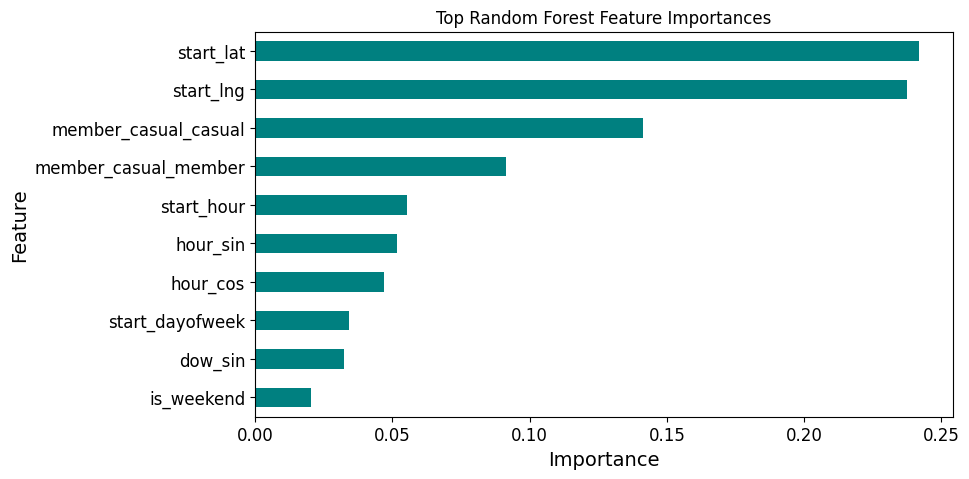

In [ ]:
# fit the final tree-based models on the training sample
forest_reg = RandomForestRegressor(random_state=42, n_jobs=-1, **best_forest_params)
forest_reg.fit(sample_train_prepared, sample_train_labels)

trip_test_prepared_for_forest = forest_pipeline.transform(trip_test)

rf_valid_pred = forest_reg.predict(trip_valid_prepared_for_forest)
rf_test_pred = forest_reg.predict(trip_test_prepared_for_forest)

rf_valid_mae, rf_valid_rmse, rf_valid_r2 = evaluate_regression(trip_valid_labels, rf_valid_pred)
rf_test_mae, rf_test_rmse, rf_test_r2 = evaluate_regression(trip_test_labels, rf_test_pred)

forest_scores = pd.DataFrame([
    {
        'model': 'random_forest',
        'valid_mae': rf_valid_mae,
        'valid_rmse': rf_valid_rmse,
        'valid_r2': rf_valid_r2,
        'test_mae': rf_test_mae,
        'test_rmse': rf_test_rmse,
        'test_r2': rf_test_r2,
    }
])

tree_full_scores = []

for candidate in tree_model_specs:
    regressor = candidate['regressor'](**candidate['params'])
    regressor.fit(sample_train_prepared, sample_train_labels)

    valid_pred = regressor.predict(trip_valid_prepared_for_forest)
    test_pred = regressor.predict(trip_test_prepared_for_forest)

    valid_mae, valid_rmse, valid_r2 = evaluate_regression(trip_valid_labels, valid_pred)
    test_mae, test_rmse, test_r2 = evaluate_regression(trip_test_labels, test_pred)

    tree_full_scores.append({
        'model': candidate['model'],
        'valid_mae': valid_mae,
        'valid_rmse': valid_rmse,
        'valid_r2': valid_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2,
    })

tree_full_scores = pd.DataFrame(tree_full_scores)

all_model_scores = pd.concat(
    [lin_scores, ridge_scores, svm_scores, forest_scores, tree_full_scores],
    ignore_index=True,
).sort_values('valid_mae')
display(all_model_scores.round(3))

cat_encoder = forest_pipeline.named_transformers_['cat']
extra_attribs = list(cat_encoder.get_feature_names_out(cat_attribs))
attributes = num_attribs + extra_attribs
feature_importances = pd.DataFrame({
    'feature': attributes,
    'importance': forest_reg.feature_importances_,
}).sort_values('importance', ascending=False)
display(feature_importances.head(10).round(3))

ax = feature_importances.head(10).sort_values('importance').plot(
    kind='barh',
    x='feature',
    y='importance',
    legend=False,
    color='teal',
)
ax.set_title('Top Random Forest Feature Importances')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.show()

# Trying to Improve the Model


In [ ]:
# try a log transform on trip duration for the histogram gradient boosting model
hgb_log_train_labels = np.log1p(sample_train_labels)

hgb_log_reg = HistGradientBoostingRegressor(
    random_state=42,
    learning_rate=0.05,
    max_depth=8,
    max_iter=200,
    min_samples_leaf=30,
)
hgb_log_reg.fit(sample_train_prepared, hgb_log_train_labels)

hgb_log_valid_pred = np.clip(np.expm1(hgb_log_reg.predict(trip_valid_prepared_for_forest)), 0, None)
hgb_log_test_pred = np.clip(np.expm1(hgb_log_reg.predict(trip_test_prepared_for_forest)), 0, None)

hgb_log_valid_mae, hgb_log_valid_rmse, hgb_log_valid_r2 = evaluate_regression(trip_valid_labels, hgb_log_valid_pred)
hgb_log_test_mae, hgb_log_test_rmse, hgb_log_test_r2 = evaluate_regression(trip_test_labels, hgb_log_test_pred)

hgb_log_scores = pd.DataFrame([
    {
        'model': 'hist_gradient_boosting_log_target',
        'valid_mae': hgb_log_valid_mae,
        'valid_rmse': hgb_log_valid_rmse,
        'valid_r2': hgb_log_valid_r2,
        'test_mae': hgb_log_test_mae,
        'test_rmse': hgb_log_test_rmse,
        'test_r2': hgb_log_test_r2,
    }
])

improved_model_scores = pd.concat([all_model_scores, hgb_log_scores], ignore_index=True).sort_values('valid_mae')
display(hgb_log_scores.round(3))
display(improved_model_scores.round(3))

,model,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
0,hist_gradient_boosting_log_target,6.599,9.783,0.041,6.079,8.959,0.02


,model,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
7,hist_gradient_boosting_log_target,6.599,9.783,0.041,6.079,8.959,0.020
0,linear_svr,6.769,10.079,-0.018,6.210,9.172,-0.027
1,hist_gradient_boosting,6.977,9.433,0.108,6.500,8.723,0.071
2,random_forest,6.986,9.459,0.103,6.494,8.743,0.067
3,decision_tree,7.085,9.617,0.073,6.588,8.893,0.035
4,extra_trees,7.110,9.649,0.067,6.611,8.914,0.030
5,linear_regression,7.161,9.643,0.068,6.650,8.880,0.037
6,ridge,7.161,9.643,0.068,6.650,8.880,0.037


Longer trips are still harder to predict, so another idea is to give them more weight during training. This keeps the same histogram gradient boosting model, but it penalizes errors on longer rides more heavily.

In [ ]:
# try weighting longer trips more heavily during training
hgb_params = next(
    candidate['params']
    for candidate in tree_model_specs
    if candidate['model'] == 'hist_gradient_boosting'
)

long_trip_cutoff = 20
sample_train_weights = np.clip(sample_train_labels / sample_train_labels.median(), 1, 4)

baseline_hgb_reg = HistGradientBoostingRegressor(**hgb_params)
baseline_hgb_reg.fit(sample_train_prepared, sample_train_labels)

weighted_hgb_reg = HistGradientBoostingRegressor(**hgb_params)
weighted_hgb_reg.fit(sample_train_prepared, sample_train_labels, sample_weight=sample_train_weights)

baseline_hgb_valid_pred = baseline_hgb_reg.predict(trip_valid_prepared_for_forest)
baseline_hgb_test_pred = baseline_hgb_reg.predict(trip_test_prepared_for_forest)

weighted_hgb_valid_pred = weighted_hgb_reg.predict(trip_valid_prepared_for_forest)
weighted_hgb_test_pred = weighted_hgb_reg.predict(trip_test_prepared_for_forest)

weighted_hgb_valid_mae, weighted_hgb_valid_rmse, weighted_hgb_valid_r2 = evaluate_regression(
    trip_valid_labels,
    weighted_hgb_valid_pred,
)
weighted_hgb_test_mae, weighted_hgb_test_rmse, weighted_hgb_test_r2 = evaluate_regression(
    trip_test_labels,
    weighted_hgb_test_pred,
)

weighted_hgb_scores = pd.DataFrame([
    {
        'model': 'hist_gradient_boosting_weighted',
        'valid_mae': weighted_hgb_valid_mae,
        'valid_rmse': weighted_hgb_valid_rmse,
        'valid_r2': weighted_hgb_valid_r2,
        'test_mae': weighted_hgb_test_mae,
        'test_rmse': weighted_hgb_test_rmse,
        'test_r2': weighted_hgb_test_r2,
    }
])

valid_long_mask = trip_valid_labels >= long_trip_cutoff
test_long_mask = trip_test_labels >= long_trip_cutoff

long_trip_scores = pd.DataFrame([
    {
        'model': 'hist_gradient_boosting',
        'valid_mae_20_plus': mean_absolute_error(trip_valid_labels[valid_long_mask], baseline_hgb_valid_pred[valid_long_mask]),
        'test_mae_20_plus': mean_absolute_error(trip_test_labels[test_long_mask], baseline_hgb_test_pred[test_long_mask]),
    },
    {
        'model': 'hist_gradient_boosting_weighted',
        'valid_mae_20_plus': mean_absolute_error(trip_valid_labels[valid_long_mask], weighted_hgb_valid_pred[valid_long_mask]),
        'test_mae_20_plus': mean_absolute_error(trip_test_labels[test_long_mask], weighted_hgb_test_pred[test_long_mask]),
    },
])

long_trip_improved_scores = pd.concat([improved_model_scores, weighted_hgb_scores], ignore_index=True).sort_values('valid_mae')
display(weighted_hgb_scores.round(3))
display(long_trip_scores.round(3))
display(long_trip_improved_scores.round(3))

,model,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
0,hist_gradient_boosting_weighted,8.755,10.458,-0.096,8.353,9.935,-0.205


,model,valid_mae_20_plus,test_mae_20_plus
0,hist_gradient_boosting,16.202,15.935
1,hist_gradient_boosting_weighted,11.879,11.645


,model,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
0,hist_gradient_boosting_log_target,6.599,9.783,0.041,6.079,8.959,0.020
1,linear_svr,6.769,10.079,-0.018,6.210,9.172,-0.027
2,hist_gradient_boosting,6.977,9.433,0.108,6.500,8.723,0.071
3,random_forest,6.986,9.459,0.103,6.494,8.743,0.067
4,decision_tree,7.085,9.617,0.073,6.588,8.893,0.035
5,extra_trees,7.110,9.649,0.067,6.611,8.914,0.030
6,linear_regression,7.161,9.643,0.068,6.650,8.880,0.037
7,ridge,7.161,9.643,0.068,6.650,8.880,0.037
8,hist_gradient_boosting_weighted,8.755,10.458,-0.096,8.353,9.935,-0.205


# Evaluate the Model

Based on validation MAE, the log-target histogram gradient boosting model is the final predictive model. The random forest is still useful for feature importance, but the error analysis below uses the selected histogram gradient boosting model.

Residual quantiles:


0.01    -9.383
0.10    -5.852
0.25    -3.794
0.50    -0.368
0.75     5.360
0.90    13.506
0.99    33.927
Name: residual, dtype: float64

,mean,median,count
member_casual,,,
casual,7.621,5.505,113235
member,5.747,4.036,527004


,mean,median,count
rideable_type,,,
classic_bike,6.360,4.221,181050
electric_bike,5.968,4.242,459189


,mean,median,count
duration_bin,,,
"(-0.001, 5.0]",5.371,5.172,148638
"(5.0, 10.0]",2.334,1.928,209810
"(10.0, 20.0]",4.611,4.161,188384
"(20.0, 40.0]",16.270,15.358,82245
"(40.0, 60.0]",35.574,34.938,11162


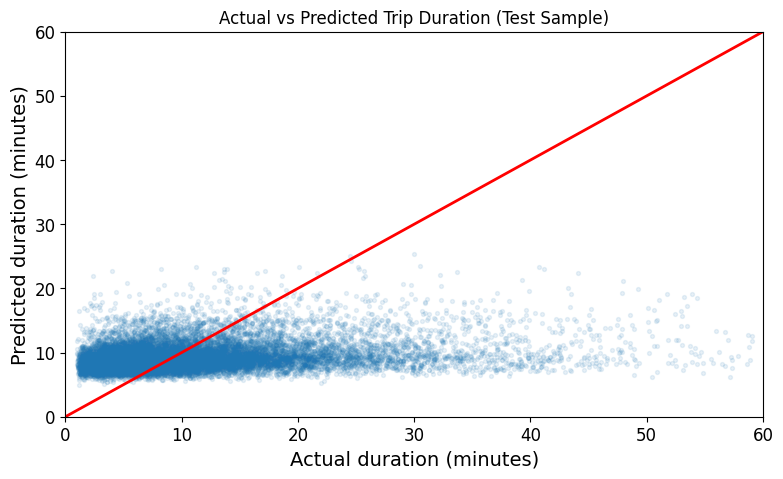

In [ ]:
test_eval = trip_test.copy()
test_eval['actual_duration'] = trip_test_labels.values
test_eval['predicted_duration'] = hgb_log_test_pred
test_eval['abs_error'] = (test_eval['actual_duration'] - test_eval['predicted_duration']).abs()
test_eval['residual'] = test_eval['actual_duration'] - test_eval['predicted_duration']
test_eval['duration_bin'] = pd.cut(
    test_eval['actual_duration'],
    bins=[0, 5, 10, 20, 40, 60],
    include_lowest=True,
)

error_by_rider = test_eval.groupby('member_casual')['abs_error'].agg(['mean', 'median', 'count'])
error_by_bike = test_eval.groupby('rideable_type')['abs_error'].agg(['mean', 'median', 'count'])
error_by_duration = test_eval.groupby('duration_bin', observed=False)['abs_error'].agg(['mean', 'median', 'count'])

print('Residual quantiles:')
display(test_eval['residual'].quantile([0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).round(3))
display(error_by_rider.round(3))
display(error_by_bike.round(3))
display(error_by_duration.round(3))

scatter_sample = test_eval.sample(n=min(15_000, len(test_eval)), random_state=42)
ax = scatter_sample.plot(
    kind='scatter',
    x='actual_duration',
    y='predicted_duration',
    alpha=0.10,
    s=8,
)
ax.plot([0, 60], [0, 60], 'r-', linewidth=2)
ax.set_title('Actual vs Predicted Trip Duration (Test Sample)')
ax.set_xlabel('Actual duration (minutes)')
ax.set_ylabel('Predicted duration (minutes)')
plt.xlim(0, 60)
plt.ylim(0, 60)
plt.show()

# Literature Review
- UCI Bike Sharing Dataset: Bike-sharing data is useful because each trip records travel duration plus departure and arrival locations, making these systems a kind of “virtual sensor network” for urban mobility.
- Yang et al. (2018): Used a Convolutional Neural Network (CNN) to predict daily Citi Bike pickups at both city and station levels. They compared it against Neural Network and ARIMA baselines.
- Jiang (2022):  Surveys deep learning models for bike-sharing prediction, especially Recurrent Neural Networks, Convolutional Neural Networks, and Graph Neural Networks for modeling temporal and spatial patterns.
- Ali et al. (2025):  Predicted bike-share trip duration and distance using Dynamic Time Warping for clustering, then trained Random Forest, CatBoost, Bagging, and GRU models on the clustered subsets.
- Compared with prior work using richer spatial, temporal, and deep learning approaches, our project uses simpler tabular models and only trip-start information, which makes the prediction setting more realistic but also limits performance.




## References


- Citi Bike. "System Data." https://citibikenyc.com/system-data
- Jiang, W. (2022). "Bike sharing usage prediction with deep learning: a survey." *Neural Computing and Applications*. https://pmc.ncbi.nlm.nih.gov/articles/PMC9185130/
- Yang, H., Xie, K., Ozbay, K., Ma, Y., & Wang, Z. (2018). "Use of Deep Learning to Predict Daily Usage of Bike Sharing Systems." *Transportation Research Record*. https://journals.sagepub.com/doi/10.1177/0361198118801354
- "Predicting Trip Duration and Distance in Bike-Sharing Systems Using Dynamic Time Warping." *Applied Artificial Intelligence* / Taylor & Francis. https://www.tandfonline.com/doi/full/10.1080/08839514.2025.2474786?af=R
